<a href="https://colab.research.google.com/github/MatiasHerrneder/bdm-2025/blob/main/TP03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Punto 1

## Funciones de entropia y GI



In [ ]:
import pandas as pd
import math

def entropia(posi, nega):
  total = posi + nega
  if total == 0:
      return 0
  p_posi = posi / total
  p_nega = nega / total
  ent = 0
  if p_posi > 0:
      ent -= p_posi * math.log2(p_posi)
  if p_nega > 0:
      ent -= p_nega * math.log2(p_nega)
  return ent

def entropia_by_dataset_S_N(data, col):
  counts = data[col].value_counts()
  posi = counts.get("SI", 0)
  nega = counts.get("NO", 0)
  return entropia(posi, nega)


def ganancia_de_informacion(data, atributo, col):
  entropia_total = entropia_by_dataset_S_N(data, col)
  valores = data[atributo].unique()
  entropia_condicional = 0

  for valor in valores:
      subset = data[data[atributo] == valor]
      peso = len(subset) / len(data)
      entropia_condicional += peso * entropia_by_dataset_S_N(subset, col)

  return entropia_total - entropia_condicional

## id3, estructura y funciones aux

In [ ]:
class NodoDecision:
  def __init__(self, atributo=None, valor=None, hijos=None, clase=None):
      self.atributo = atributo   # atributo usado para dividir (ej: "Cielo")
      self.valor = valor         # valor de la rama que lleva a este nodo (opcional)
      self.hijos = hijos or {}   # dict: valor → NodoDecision
      self.clase = clase         # si es hoja, almacena la clase ("SI"/"NO")

  def es_hoja(self):
      return self.clase is not None


def id3(data, clase_col, atributos=None):
  # Si no se pasan atributos, usar todas las columnas excepto la clase
    if atributos is None:
        atributos = [col for col in data.columns if col != clase_col]

    # Caso base 1: todos los ejemplos son de la misma clase
    clases_unicas = data[clase_col].unique()
    if len(clases_unicas) == 1:
        return NodoDecision(clase=clases_unicas[0])

    # Caso base 2: no quedan atributos
    if len(atributos) == 0:
        clase_mas_comun = data[clase_col].mode()[0]
        return NodoDecision(clase=clase_mas_comun)

    # Elegir el atributo con mayor ganancia
    ganancias = {atrib: ganancia_de_informacion(data, atrib, clase_col) for atrib in atributos}
    mejor_atributo = max(ganancias, key=ganancias.get)

    # Crear nodo raíz con ese atributo
    nodo = NodoDecision(atributo=mejor_atributo)

    # Crear subárboles por cada valor posible
    for valor in data[mejor_atributo].unique():
        subset = data[data[mejor_atributo] == valor]

        if subset.empty:
            clase_mas_comun = data[clase_col].mode()[0]
            nodo.hijos[valor] = NodoDecision(clase=clase_mas_comun)
        else:
            nuevos_atributos = [a for a in atributos if a != mejor_atributo]
            nodo.hijos[valor] = id3(subset, clase_col, nuevos_atributos)

    return nodo


def imprimir_arbol(nodo, nivel=0):
  sangria = "  |" * nivel
  if nodo.es_hoja():
      print(f"{sangria} → {nodo.clase}")
  else:
      print(f"{sangria}  [Atributo: {nodo.atributo}]")
      for valor, hijo in nodo.hijos.items():
          print(f"{sangria}  ├─ {valor}:")
          imprimir_arbol(hijo, nivel + 1)

## Prueba de ejemplo

In [ ]:
data = pd.DataFrame({
    'PRONÓSTICO': ['Soleado', 'Soleado', 'Nublado', 'Lluvioso', 'Lluvioso', 'Lluvioso', 'Nublado', 'Soleado', 'Soleado', 'Lluvioso', 'Soleado', 'Nublado', 'Nublado', 'Lluvioso'],
    'TEMPERATURA': ['Calor', 'Calor', 'Calor', 'templado', 'Frío', 'Frío', 'Frío', 'templado', 'Frío', 'templado', 'templado', 'templado', 'Calor', 'templado'],
    'HUMEDAD': ['Alta', 'Alta', 'Alta', 'Alta', 'normal', 'normal', 'normal', 'Alta', 'normal', 'normal', 'normal', 'Alta', 'normal', 'Alta'],
    'VIENTO': ['leve', 'fuerte', 'leve', 'leve', 'leve', 'fuerte', 'fuerte', 'leve', 'leve', 'leve', 'fuerte', 'fuerte', 'leve', 'fuerte'],
    'ASADO': ['no', 'no', 'si', 'si', 'si', 'no', 'si', 'no', 'si', 'si', 'si', 'si', 'si', 'no']
})


arbol = id3(data, "ASADO")
imprimir_arbol(arbol)

  [Atributo: PRONÓSTICO]
  ├─ Soleado:
  |  [Atributo: TEMPERATURA]
  |  ├─ Calor:
  |  | → no
  |  ├─ templado:
  |  |  [Atributo: HUMEDAD]
  |  |  ├─ Alta:
  |  |  | → no
  |  |  ├─ normal:
  |  |  | → si
  |  ├─ Frío:
  |  | → si
  ├─ Nublado:
  | → si
  ├─ Lluvioso:
  |  [Atributo: TEMPERATURA]
  |  ├─ templado:
  |  |  [Atributo: HUMEDAD]
  |  |  ├─ Alta:
  |  |  |  [Atributo: VIENTO]
  |  |  |  ├─ leve:
  |  |  |  | → si
  |  |  |  ├─ fuerte:
  |  |  |  | → no
  |  |  ├─ normal:
  |  |  | → si
  |  ├─ Frío:
  |  |  [Atributo: HUMEDAD]
  |  |  ├─ normal:
  |  |  |  [Atributo: VIENTO]
  |  |  |  ├─ leve:
  |  |  |  | → si
  |  |  |  ├─ fuerte:
  |  |  |  | → no


# Punto 2

## Exploracion de metadata

In [ ]:
!pip install ucimlrepo
from sklearn.tree import DecisionTreeClassifier
from ucimlrepo import fetch_ucirepo

# fetch dataset
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17)

# data (as pandas dataframes)
X = breast_cancer_wisconsin_diagnostic.data.features
y = breast_cancer_wisconsin_diagnostic.data.targets

# metadata
print(breast_cancer_wisconsin_diagnostic.metadata)

{'uci_id': 17, 'name': 'Breast Cancer Wisconsin (Diagnostic)', 'repository_url': 'https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic', 'data_url': 'https://archive.ics.uci.edu/static/public/17/data.csv', 'abstract': 'Diagnostic Wisconsin Breast Cancer Database.', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 569, 'num_features': 30, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['Diagnosis'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1993, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C5DW2B', 'creators': ['William Wolberg', 'Olvi Mangasarian', 'Nick Street', 'W. Street'], 'intro_paper': {'ID': 230, 'type': 'NATIVE', 'title': 'Nuclear feature extraction for breast tumor diagnosis', 'authors': 'W. Street, W. Wolberg, O. Mangasarian', 'venue': 'Electronic imaging', 'year': 1993, 'journal': None, 'DOI': '1

## Primer arbol de decision

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Decision Tree Classifier
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train, y_train)

# Predict on the test set
y_pred = dt_classifier.predict(X_test)

# Evaluate the classifier
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of the Decision Tree Classifier: {accuracy:.4f}")

Accuracy of the Decision Tree Classifier: 0.9474


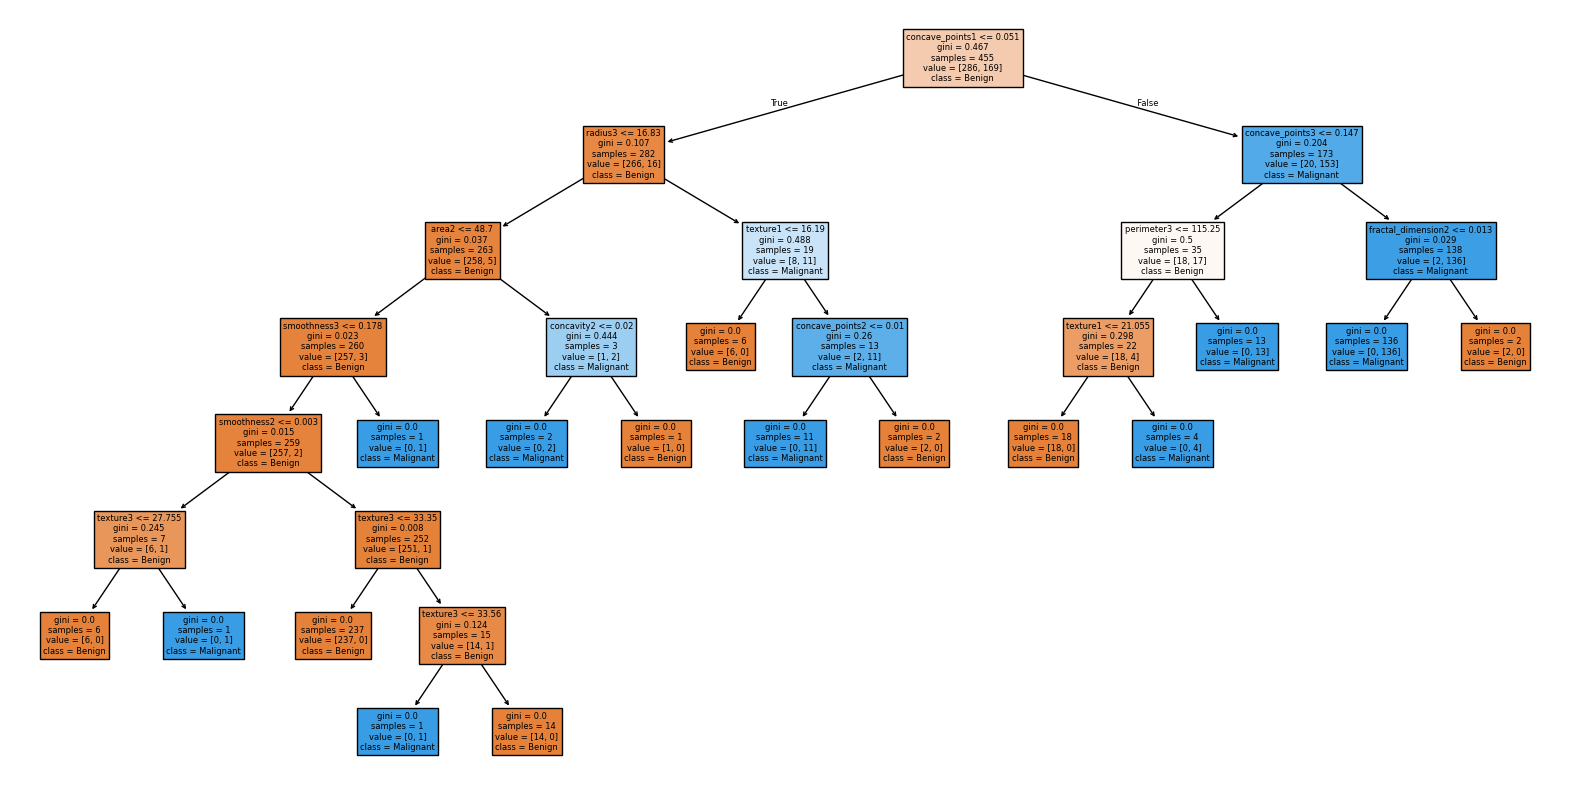

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(dt_classifier, feature_names=X.columns, class_names=['Benign', 'Malignant'], filled=True)
plt.show()

## Distintas configuraciones de arbol de decision

### Parametros:

In [ ]:
# Key parameters of DecisionTreeClassifier and their influence:

# 1. criterion: The function to measure the quality of a split.
#    - 'gini': Uses the Gini impurity.
#    - 'entropy': Uses the information gain (based on entropy).
#    Influence: Determines how the best split is chosen at each node. Different criteria can lead to different tree structures and potentially different performance.

# 2. splitter: The strategy used to choose the split at each node.
#    - 'best': Chooses the best split among all candidate features.
#    - 'random': Chooses a random subset of features and finds the best split among them.
#    Influence: Affects the randomness of the tree building process and can be useful for creating ensembles.

# 3. max_depth: The maximum depth of the tree.
#    Influence: Controls the complexity of the tree. A smaller max_depth prevents overfitting but might underfit if too small.

# 4. min_samples_split: The minimum number of samples required to split an internal node.
#    Influence: Controls when splitting stops. Larger values prevent splitting on small groups of samples, reducing overfitting.

# 5. min_samples_leaf: The minimum number of samples required to be at a leaf node.
#    Influence: Ensures that each leaf has a minimum number of samples, preventing the creation of leaves with very few samples, which can be sensitive to noise.

# 6. max_features: The number of features to consider when looking for the best split.
#    - int: Consider `max_features` at each split.
#    - float: Consider `max_features * n_features` at each split.
#    - "sqrt": Consider `sqrt(n_features)` features.
#    - "log2": Consider `log2(n_features)` features.
#    - None: Consider all features.
#    Influence: Controls the randomness of the tree and can be useful for preventing overfitting and for ensemble methods.

# 7. random_state: Controls the randomness of the estimator.
#    Influence: Used for reproducibility, especially when `splitter` is 'random' or `max_features` is set. Setting a random_state ensures that the same splits are chosen each time the code is run.

### Medidas

In [ ]:
# Accuracy: This is the most straightforward metric. It measures the proportion of correctly classified instances out of the total number of instances.
    # Meaning: A higher accuracy indicates that the model is correctly classifying a larger percentage of the data.
# Precision: This metric is important when the cost of a false positive is high. It measures the proportion of true positive predictions among all positive predictions.
    # Meaning: High precision means that when the model predicts a positive outcome (in this case, Malignant 'M'), it is very likely to be correct. It tells you how many of the predicted 'M' cases were actually 'M'.
# Recall (Sensitivity): This metric is important when the cost of a false negative is high. It measures the proportion of true positive predictions among all actual positive instances.
    # Meaning: High recall means that the model is good at finding all the actual positive cases (all the actual 'M' cases). It tells you how many of the actual 'M' cases the model correctly identified.
# F1-score: This is the harmonic mean of precision and recall. It provides a single score that balances both concerns.
    # Meaning: The F1-score is useful when you need a balance between precision and recall, especially if you have an uneven class distribution. A high F1-score indicates that the model has a good balance of both high precision and high recall.

### Evaluacion de distintas configuraciones


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Define a list of parameter combinations to explore
param_grid = [
    {'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2},
    {'criterion': 'entropy', 'max_depth': 3, 'min_samples_split': 2},
    {'criterion': 'gini', 'max_depth': 5, 'min_samples_split': 5},
    {'criterion': 'entropy', 'max_depth': 5, 'min_samples_split': 5},
    {'criterion': 'gini', 'max_depth': None, 'min_samples_split': 2},
    {'criterion': 'entropy', 'max_depth': None, 'min_samples_split': 2},
    {'criterion': 'gini', 'max_depth': 5, 'min_samples_split': 10},
    {'criterion': 'entropy', 'max_depth': 5, 'min_samples_split': 10},
]

results = []

# Iterate through each parameter combination
for params in param_grid:
    print(f"Training with parameters: {params}")

    # Instantiate and train the Decision Tree Classifier
    dt_classifier = DecisionTreeClassifier(**params, random_state=42)
    dt_classifier.fit(X_train, y_train)

    # Predict on the test set
    y_pred = dt_classifier.predict(X_test)

    # Evaluate the classifier
    accuracy = accuracy_score(y_test, y_pred)
    # Calculate precision, recall, and F1-score for the 'M' class (Malignant)
    precision = precision_score(y_test, y_pred, pos_label='M')
    recall = recall_score(y_test, y_pred, pos_label='M')
    f1 = f1_score(y_test, y_pred, pos_label='M')


    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision (M): {precision:.4f}")
    print(f"Recall (M): {recall:.4f}")
    print(f"F1-score (M): {f1:.4f}")
    print("-" * 30)

    # Store the results
    results.append({'parameters': params, 'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1_score': f1})


Training with parameters: {'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}
Accuracy: 0.9474
Precision (M): 0.9512
Recall (M): 0.9070
F1-score (M): 0.9286
------------------------------
Training with parameters: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_split': 2}
Accuracy: 0.9649
Precision (M): 1.0000
Recall (M): 0.9070
F1-score (M): 0.9512
------------------------------
Training with parameters: {'criterion': 'gini', 'max_depth': 5, 'min_samples_split': 5}
Accuracy: 0.9474
Precision (M): 0.9302
Recall (M): 0.9302
F1-score (M): 0.9302
------------------------------
Training with parameters: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_split': 5}
Accuracy: 0.9474
Precision (M): 0.9744
Recall (M): 0.8837
F1-score (M): 0.9268
------------------------------
Training with parameters: {'criterion': 'gini', 'max_depth': None, 'min_samples_split': 2}
Accuracy: 0.9474
Precision (M): 0.9302
Recall (M): 0.9302
F1-score (M): 0.9302
------------------------------
T

In [ ]:
import pandas as pd

# Convert the results list to a DataFrame
results_df = pd.DataFrame(results)

# Sort the DataFrame by F1-score in descending order
results_df_sorted = results_df.sort_values(by='f1_score', ascending=False)

# Display the sorted DataFrame
display(results_df_sorted)

# Analyze the DataFrame to identify the best-performing configurations
print("\nAnalysis of Results:")
best_config = results_df_sorted.iloc[0]
print(f"The best performing configuration based on F1-score is:\n{best_config['parameters']}")
print(f"Metrics for the best configuration:\nAccuracy: {best_config['accuracy']:.4f}, Precision (M): {best_config['precision']:.4f}, Recall (M): {best_config['recall']:.4f}, F1-score (M): {best_config['f1_score']:.4f}")

# You can further analyze by looking at other metrics or top N configurations
print("\nTop 3 configurations by F1-score:")
display(results_df_sorted.head(3))

,parameters,accuracy,precision,recall,f1_score
1,"{'criterion': 'entropy', 'max_depth': 3, 'min_...",0.964912,1.000000,0.906977,0.951220
2,"{'criterion': 'gini', 'max_depth': 5, 'min_sam...",0.947368,0.930233,0.930233,0.930233
6,"{'criterion': 'gini', 'max_depth': 5, 'min_sam...",0.947368,0.930233,0.930233,0.930233
4,"{'criterion': 'gini', 'max_depth': None, 'min_...",0.947368,0.930233,0.930233,0.930233
0,"{'criterion': 'gini', 'max_depth': 3, 'min_sam...",0.947368,0.951220,0.906977,0.928571
3,"{'criterion': 'entropy', 'max_depth': 5, 'min_...",0.947368,0.974359,0.883721,0.926829
5,"{'criterion': 'entropy', 'max_depth': None, 'm...",0.947368,0.974359,0.883721,0.926829
7,"{'criterion': 'entropy', 'max_depth': 5, 'min_...",0.947368,0.974359,0.883721,0.926829



Analysis of Results:
The best performing configuration based on F1-score is:
{'criterion': 'entropy', 'max_depth': 3, 'min_samples_split': 2}
Metrics for the best configuration:
Accuracy: 0.9649, Precision (M): 1.0000, Recall (M): 0.9070, F1-score (M): 0.9512

Top 3 configurations by F1-score:


,parameters,accuracy,precision,recall,f1_score
1,"{'criterion': 'entropy', 'max_depth': 3, 'min_...",0.964912,1.000000,0.906977,0.951220
2,"{'criterion': 'gini', 'max_depth': 5, 'min_sam...",0.947368,0.930233,0.930233,0.930233
6,"{'criterion': 'gini', 'max_depth': 5, 'min_sam...",0.947368,0.930233,0.930233,0.930233


# Punto 3

In [ ]:
import kagglehub
import os
import pandas as pd

dd_path = kagglehub.dataset_download("uciml/pima-indians-diabetes-database")
csv_file_path = os.path.join(dd_path, 'diabetes.csv')
dd = pd.read_csv(csv_file_path)

display(dd.head())

outcome_dist = dd["Outcome"].value_counts()
print(outcome_dist)

Using Colab cache for faster access to the 'pima-indians-diabetes-database' dataset.


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Outcome
0    500
1    268
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, cohen_kappa_score\

X = dd.drop('Outcome', axis=1)
y = dd['Outcome']

# 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

dt_classifier_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)

dt_classifier_entropy.fit(X_train, y_train)

y_pred = dt_classifier_entropy.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
kappa = cohen_kappa_score(y_test, y_pred)

print(f"Decision Tree Classifier using Entropy:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Kappa: {kappa:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

Decision Tree Classifier using Entropy:
Accuracy: 0.7013
Kappa: 0.3269
Precision: 0.5833
Recall: 0.5185
F1-score: 0.5490


In [ ]:
# Define features (X) and target (y) - Assuming 'dd' DataFrame is already loaded
X = dd.drop('Outcome', axis=1)
y = dd['Outcome']

# Split the data into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Define a list of parameter combinations to explore
param_grid = [
    {'max_depth': 3, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_leaf_nodes': None},
    {'max_depth': 5, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_leaf_nodes': None},
    {'max_depth': 10, 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_leaf_nodes': None},
    {'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_leaf_nodes': None},
    {'max_depth': 5, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_leaf_nodes': 10},
    {'max_depth': 5, 'min_samples_split': 5, 'min_samples_leaf': 5, 'max_leaf_nodes': 20},
    {'max_depth': 7, 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_leaf_nodes': None},
    {'max_depth': 7, 'min_samples_split': 5, 'min_samples_leaf': 5, 'max_leaf_nodes': 15},
    {'max_depth': 10, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_leaf_nodes': None},
    {'max_depth': None, 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_leaf_nodes': 25},
]

results = []

# Iterate through each parameter combination
for params in param_grid:
    print(f"Training with parameters: {params}")

    # Instantiate and train the Decision Tree Classifier with entropy criterion
    dt_classifier = DecisionTreeClassifier(criterion='entropy', **params, random_state=42)
    dt_classifier.fit(X_train, y_train)

    # Predict on the test set
    y_pred = dt_classifier.predict(X_test)

    # Evaluate the classifier
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred) # Assuming 1 is the positive class (diabetes)
    recall = recall_score(y_test, y_pred)     # Assuming 1 is the positive class (diabetes)
    f1 = f1_score(y_test, y_pred)         # Assuming 1 is the positive class (diabetes)
    kappa = cohen_kappa_score(y_test, y_pred)


    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")
    print(f"Cohen's Kappa: {kappa:.4f}")
    print("-" * 30)

    # Store the results
    results.append({'parameters': params, 'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1_score': f1, 'kappa': kappa})

# Convert the results list to a DataFrame
results_df = pd.DataFrame(results)

# Display the results DataFrame
display(results_df)

Training with parameters: {'max_depth': 3, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_leaf_nodes': None}
Accuracy: 0.6948
Precision: 0.6522
Recall: 0.2778
F1-score: 0.3896
Cohen's Kappa: 0.2279
------------------------------
Training with parameters: {'max_depth': 5, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_leaf_nodes': None}
Accuracy: 0.7922
Precision: 0.6964
Recall: 0.7222
F1-score: 0.7091
Cohen's Kappa: 0.5476
------------------------------
Training with parameters: {'max_depth': 10, 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_leaf_nodes': None}
Accuracy: 0.6883
Precision: 0.5682
Recall: 0.4630
F1-score: 0.5102
Cohen's Kappa: 0.2851
------------------------------
Training with parameters: {'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_leaf_nodes': None}
Accuracy: 0.7013
Precision: 0.5833
Recall: 0.5185
F1-score: 0.5490
Cohen's Kappa: 0.3269
------------------------------
Training with parameters: {'max_depth': 5, 'min_samples_spl

,parameters,accuracy,precision,recall,f1_score,kappa
0,"{'max_depth': 3, 'min_samples_split': 2, 'min_...",0.694805,0.652174,0.277778,0.389610,0.227864
1,"{'max_depth': 5, 'min_samples_split': 5, 'min_...",0.792208,0.696429,0.722222,0.709091,0.547558
2,"{'max_depth': 10, 'min_samples_split': 10, 'mi...",0.688312,0.568182,0.462963,0.510204,0.285106
3,"{'max_depth': None, 'min_samples_split': 2, 'm...",0.701299,0.583333,0.518519,0.549020,0.326872
4,"{'max_depth': 5, 'min_samples_split': 2, 'min_...",0.805195,0.714286,0.740741,0.727273,0.575835
5,"{'max_depth': 5, 'min_samples_split': 5, 'min_...",0.792208,0.696429,0.722222,0.709091,0.547558
6,"{'max_depth': 7, 'min_samples_split': 10, 'min...",0.694805,0.585366,0.444444,0.505263,0.290531
7,"{'max_depth': 7, 'min_samples_split': 5, 'min_...",0.798701,0.716981,0.703704,0.710280,0.556072
8,"{'max_depth': 10, 'min_samples_split': 5, 'min...",0.655844,0.510204,0.462963,0.485437,0.227815
9,"{'max_depth': None, 'min_samples_split': 10, '...",0.727273,0.650000,0.481481,0.553191,0.363135


In [ ]:
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score # Removed cohen_kappa_score import
import pandas as pd
import numpy as np

# Assuming 'dd' DataFrame is already loaded and X and y are defined

# Define features (X) and target (y)
X = dd.drop('Outcome', axis=1)
y = dd['Outcome']

# Define a list of parameter combinations to explore (same as before)
param_grid = [
    {'max_depth': 3, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_leaf_nodes': None},
    {'max_depth': 5, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_leaf_nodes': None},
    {'max_depth': 10, 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_leaf_nodes': None},
    {'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_leaf_nodes': None},
    {'max_depth': 5, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_leaf_nodes': 10},
    {'max_depth': 5, 'min_samples_split': 5, 'min_samples_leaf': 5, 'max_leaf_nodes': 20},
    {'max_depth': 7, 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_leaf_nodes': None},
    {'max_depth': 7, 'min_samples_split': 5, 'min_samples_leaf': 5, 'max_leaf_nodes': 15},
    {'max_depth': 10, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_leaf_nodes': None},
    {'max_depth': None, 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_leaf_nodes': 25},
]

results_cv = []

# Define the cross-validation strategy (5-folds, stratified)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Iterate through each parameter combination
for params in param_grid:
    print(f"Training with parameters: {params}")

    # Instantiate the Decision Tree Classifier with entropy criterion
    dt_classifier = DecisionTreeClassifier(criterion='entropy', **params, random_state=42)

    # Perform cross-validation
    cv_results = cross_validate(dt_classifier, X, y, cv=cv,
                                scoring=('accuracy', 'precision', 'recall', 'f1'), # Removed 'kappa'
                                return_train_score=False) # We usually care about test scores

    # Calculate the mean of the scores across all folds
    mean_accuracy = np.mean(cv_results['test_accuracy'])
    mean_precision = np.mean(cv_results['test_precision'])
    mean_recall = np.mean(cv_results['test_recall'])
    mean_f1 = np.mean(cv_results['test_f1'])
    # Removed mean_kappa calculation


    print(f"Mean Accuracy: {mean_accuracy:.4f}")
    print(f"Mean Precision: {mean_precision:.4f}")
    print(f"Mean Recall: {mean_recall:.4f}")
    print(f"Mean F1-score: {mean_f1:.4f}")
    # Removed Mean Cohen's Kappa print
    print("-" * 30)

    # Store the results
    results_cv.append({
        'parameters': params,
        'mean_accuracy': mean_accuracy,
        'mean_precision': mean_precision,
        'mean_recall': mean_recall,
        'mean_f1_score': mean_f1,
        # Removed mean_kappa from results
    })

# Convert the results list to a DataFrame
results_cv_df = pd.DataFrame(results_cv)

# Display the results DataFrame
display(results_cv_df)

# You can further analyze the DataFrame to identify the best-performing configurations
# For example, sorting by Mean F1-score:
# results_cv_df_sorted_f1 = results_cv_df.sort_values(by='mean_f1_score', ascending=False)
# display(results_cv_df_sorted_f1)

Training with parameters: {'max_depth': 3, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_leaf_nodes': None}
Mean Accuracy: 0.7486
Mean Precision: 0.6882
Mean Recall: 0.5339
Mean F1-score: 0.5932
------------------------------
Training with parameters: {'max_depth': 5, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_leaf_nodes': None}
Mean Accuracy: 0.7434
Mean Precision: 0.6549
Mean Recall: 0.5855
Mean F1-score: 0.6076
------------------------------
Training with parameters: {'max_depth': 10, 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_leaf_nodes': None}
Mean Accuracy: 0.7044
Mean Precision: 0.5845
Mean Recall: 0.5485
Mean F1-score: 0.5646
------------------------------
Training with parameters: {'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_leaf_nodes': None}
Mean Accuracy: 0.6953
Mean Precision: 0.5663
Mean Recall: 0.5560
Mean F1-score: 0.5600
------------------------------
Training with parameters: {'max_depth': 5, 'min_samples_split': 2, 

,parameters,mean_accuracy,mean_precision,mean_recall,mean_f1_score
0,"{'max_depth': 3, 'min_samples_split': 2, 'min_...",0.748646,0.688241,0.533892,0.593192
1,"{'max_depth': 5, 'min_samples_split': 5, 'min_...",0.743383,0.654879,0.585535,0.607569
2,"{'max_depth': 10, 'min_samples_split': 10, 'mi...",0.704363,0.584482,0.548498,0.564603
3,"{'max_depth': None, 'min_samples_split': 2, 'm...",0.695264,0.566267,0.556045,0.559974
4,"{'max_depth': 5, 'min_samples_split': 2, 'min_...",0.742093,0.627431,0.656464,0.638813
5,"{'max_depth': 5, 'min_samples_split': 5, 'min_...",0.742085,0.652985,0.589448,0.610764
6,"{'max_depth': 7, 'min_samples_split': 10, 'min...",0.722570,0.618158,0.585604,0.590660
7,"{'max_depth': 7, 'min_samples_split': 5, 'min_...",0.732968,0.637234,0.615653,0.614594
8,"{'max_depth': 10, 'min_samples_split': 5, 'min...",0.697886,0.576091,0.515024,0.542372
9,"{'max_depth': None, 'min_samples_split': 10, '...",0.736839,0.642670,0.574284,0.602949
